In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### Dataset Ingestion & Initial Inspection

In [25]:
df = pd.read_csv("data.csv")
print(df.head())

    1st   2nd   3rd   4th   5th  College Code  Gender  Roll  Roll no.  \
0  8.11  7.68  7.11  7.43  8.18           115  Female   NaN   17020.0   
1  6.48  5.90  4.15  4.29  4.96           115    Male   NaN   17021.0   
2  8.41  8.24  7.52  8.25  7.75           115  Female   NaN   17022.0   
3  7.33  6.83  6.33  6.79  6.89           115    Male   NaN   17023.0   
4  7.89  7.34  7.22  7.32  7.46           115    Male   NaN   17024.0   

   Subject Code  
0            16  
1            16  
2            16  
3            16  
4            16  


In [ ]:
### Data Auditing

In [26]:
df.describe()

,1st,2nd,3rd,4th,5th,College Code,Roll,Roll no.,Subject Code
count,176.000000,174.000000,176.00000,173.000000,172.000000,178.000000,132.000000,46.000000,178.000000
mean,7.038864,6.943391,6.62250,7.027746,7.432558,152.983146,17040.666667,17042.500000,18.359551
std,0.859521,0.881088,0.91926,1.035675,1.068866,48.357599,13.622874,13.422618,4.782849
min,3.850000,3.900000,3.96000,4.290000,4.000000,115.000000,17017.000000,17020.000000,16.000000
25%,6.440000,6.380000,6.14000,6.330000,6.750000,115.000000,17029.000000,17031.250000,16.000000
50%,7.070000,6.800000,6.68500,7.070000,7.590000,116.000000,17040.000000,17042.500000,16.000000
75%,7.590000,7.612500,7.26000,7.860000,8.210000,165.000000,17051.000000,17053.750000,16.000000
max,9.150000,9.210000,9.59000,9.310000,9.460000,241.000000,17067.000000,17065.000000,28.000000


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   1st           176 non-null    float64
 1   2nd           174 non-null    float64
 2   3rd           176 non-null    float64
 3   4th           173 non-null    float64
 4   5th           172 non-null    float64
 5   College Code  178 non-null    int64  
 6   Gender        177 non-null    str    
 7   Roll          132 non-null    float64
 8   Roll no.      46 non-null     float64
 9   Subject Code  178 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.0 KB


In [ ]:
### Data Cleaning

In [28]:
df = pd.read_csv("data.csv")
df['Roll no.'] = df['Roll no.'].combine_first(df['Roll'])
df['Roll no.'] = df['Roll no.'].astype('Int64')
df = df.drop(columns=['Roll'])
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   1st           176 non-null    float64
 1   2nd           174 non-null    float64
 2   3rd           176 non-null    float64
 3   4th           173 non-null    float64
 4   5th           172 non-null    float64
 5   College Code  178 non-null    int64  
 6   Gender        177 non-null    str    
 7   Roll no.      178 non-null    Int64  
 8   Subject Code  178 non-null    int64  
dtypes: Int64(1), float64(5), int64(2), str(1)
memory usage: 12.8 KB
None


In [ ]:
### Categorical Cleaning & Demographic Distribution

In [29]:
df["Gender"] = df["Gender"].str.replace("Male","M")
df["Gender"] = df["Gender"].str.replace("Female","F")
df.head()

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,F,17020,16
1,6.48,5.90,4.15,4.29,4.96,115,M,17021,16
2,8.41,8.24,7.52,8.25,7.75,115,F,17022,16
3,7.33,6.83,6.33,6.79,6.89,115,M,17023,16
4,7.89,7.34,7.22,7.32,7.46,115,M,17024,16


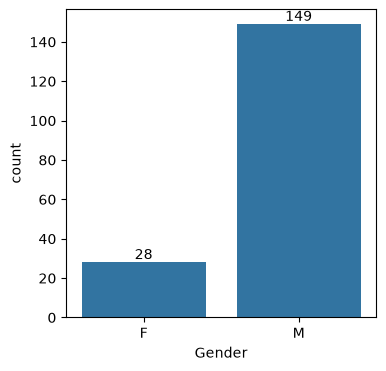

In [30]:
plt.figure(figsize=(4,4))
ax=sns.countplot(data=df,x="Gender")
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
### Metric Engineering: CGPA Calculation & Merit Ranking

In [31]:
semesters = ['1st', '2nd', '3rd', '4th', '5th']
df['CGPA'] = df[semesters].mean(axis=1).round(2)
df.sort_values(by='CGPA', ascending=False)[['Roll no.', 'College Code', 'CGPA']].head(5)

,Roll no.,College Code,CGPA
135,17060,116,9.34
115,17040,116,8.92
27,17047,115,8.56
96,17021,116,8.53
111,17036,116,8.49


In [ ]:
### Inter-College Performance Benchmarking

In [32]:
college_summary = df.groupby('College Code')['CGPA'].agg(
    Student_Count='count',
    Average_CGPA='mean',
    Median_CGPA='median',
    Highest_CGPA='max',
    Std_Dev='std'
).round(2)

college_summary

,Student_Count,Average_CGPA,Median_CGPA,Highest_CGPA,Std_Dev
College Code,,,,,
115,46,7.16,7.26,8.56,0.86
116,51,6.94,6.68,9.34,0.92
165,45,6.90,7.03,8.41,0.97
241,35,6.96,6.97,8.31,0.74


In [ ]:
### Cohort Trajectory & Difficulty Dip Analysis

,1st,2nd,3rd,4th,5th
mean,7.04,6.94,6.62,7.03,7.43
median,7.07,6.80,6.68,7.07,7.59
std,0.86,0.88,0.92,1.04,1.07
min,3.85,3.90,3.96,4.29,4.00
max,9.15,9.21,9.59,9.31,9.46


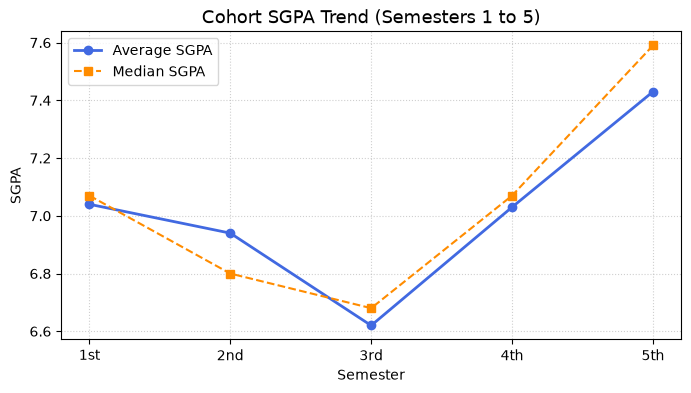

In [33]:
sem_summary = df[semesters].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
display(sem_summary)

plt.figure(figsize=(8, 4))
plt.plot(semesters, sem_summary.loc['mean'], marker='o', color='royalblue', linewidth=2, label='Average SGPA')
plt.plot(semesters, sem_summary.loc['median'], marker='s', color='darkorange', linestyle='--', label='Median SGPA')
plt.title("Cohort SGPA Trend (Semesters 1 to 5)", fontsize=13)
plt.xlabel("Semester")
plt.ylabel("SGPA")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
### Academic Trajectory: Highest Gainers & Steepest Declines

In [34]:
df['Improvement'] = (df['5th'] - df['1st']).round(2)
print("Biggest Academic Turnarounds")
display(df.sort_values(by='Improvement', ascending=False)[['Roll no.', 'College Code', '1st', '5th', 'Improvement']].head(3))
print("Steepest Academic Drops")
display(df.sort_values(by='Improvement', ascending=True)[['Roll no.', 'College Code', '1st', '5th', 'Improvement']].head(3))

Biggest Academic Turnarounds


,Roll no.,College Code,1st,5th,Improvement
129,17054,116,5.52,7.79,2.27
29,17049,115,5.74,7.61,1.87
84,17059,165,6.22,7.96,1.74


Steepest Academic Drops


,Roll no.,College Code,1st,5th,Improvement
165,17040,241,7.07,4.77,-2.30
100,17025,116,6.59,4.96,-1.63
151,17026,241,6.96,5.35,-1.61


In [ ]:
### Semester Performance Correlation Heatmap

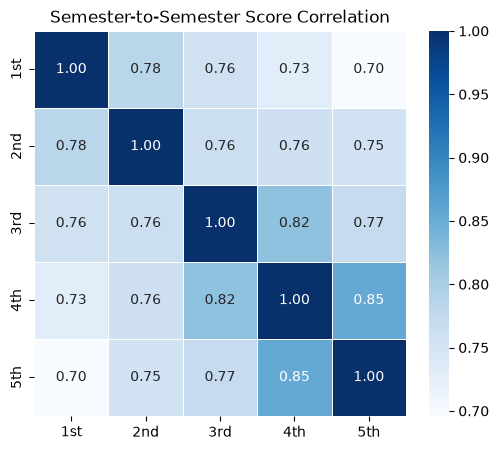

In [35]:
corr_matrix = df[semesters].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5, cbar=True)
plt.title("Semester-to-Semester Score Correlation", fontsize=12)
plt.show()

In [ ]:
### Predictive Modeling & Student Diagnostic Lookup

Report for Roll No: 17054 (College 115)
CGPA: 6.88 | Overall Improvement: -1.40
Scores (1st - 5th): [np.float64(8.04), np.float64(6.69), np.float64(6.37), np.float64(6.64), np.float64(6.64)]
Model Predicted 5th Sem: 6.98 (Actual: 6.64)


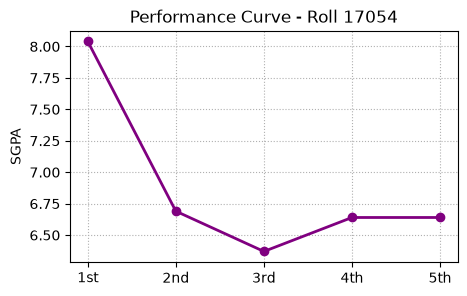

In [38]:
df['Improvement'] = (df['5th'] - df['1st']).round(2)
clean_df = df.dropna(subset=['1st', '2nd', '3rd', '4th', '5th']).copy()

X = clean_df[['1st', '2nd', '3rd', '4th']].values
y = clean_df['5th'].values
X_design = np.c_[np.ones(X.shape[0]), X]

weights, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
clean_df['Predicted_5th'] = np.round(X_design @ weights, 2)

def student_lookup(roll_no):
    student = clean_df[clean_df['Roll no.'] == roll_no]
    if student.empty:
        print(f"Roll number {roll_no} not found or has missing semester records.")
        return
    
    data = student.iloc[0]
    print(f"Report for Roll No: {int(data['Roll no.'])} (College {int(data['College Code'])})")
    print(f"CGPA: {data['CGPA']} | Overall Improvement: {data['Improvement']:+0.2f}")
    print(f"Scores (1st - 5th): {list(data[semesters])}")
    print(f"Model Predicted 5th Sem: {data['Predicted_5th']} (Actual: {data['5th']})")

    plt.figure(figsize=(5, 3))
    plt.plot(semesters, data[semesters], marker='o', color='purple', linewidth=2)
    plt.title(f"Performance Curve - Roll {int(roll_no)}")
    plt.ylabel("SGPA")
    plt.grid(True, linestyle=':')
    plt.show()

student_lookup(17054)

In [ ]:
### Early Warning & Academic Status Classifier

In [42]:
def classify_student(row):
    if row[semesters].isna().any():
        return 'Missing Exams / Incomplete'
    elif row['Improvement'] <= -1.0:
        return 'Critical Drop'
    elif row['CGPA'] >= 8.0:
        return 'High Achiever'
    elif row['CGPA'] < 6.0:
        return 'Academic Probation'
    else:
        return 'Consistent / Average'

df['Academic_Status'] = df.apply(classify_student, axis=1)

print(" Cohort Breakdown across 178 Students")
display(df['Academic_Status'].value_counts())

print("\n Students Needing Intervention (Critical Drop or Probation) ")
display(df[df['Academic_Status'].isin(['Critical Drop', 'Academic Probation'])][['Roll no.', 'College Code', 'CGPA', 'Improvement', 'Academic_Status']].head(10))

 Cohort Breakdown across 178 Students


Academic_Status
Consistent / Average          122
High Achiever                  23
Academic Probation             13
Critical Drop                  11
Missing Exams / Incomplete      9
Name: count, dtype: int64


 Students Needing Intervention (Critical Drop or Probation) 


,Roll no.,College Code,CGPA,Improvement,Academic_Status
1,17021,115,5.16,-1.52,Critical Drop
9,17029,115,6.55,-1.12,Critical Drop
11,17031,115,5.86,-0.39,Academic Probation
12,17032,115,5.89,1.08,Academic Probation
34,17054,115,6.88,-1.40,Critical Drop
40,17060,115,5.12,-0.95,Academic Probation
47,17022,165,5.20,0.88,Academic Probation
76,17051,165,6.42,-1.20,Critical Drop
79,17054,165,5.58,0.68,Academic Probation
81,17056,165,5.73,0.00,Academic Probation


In [ ]:
### Reporting & Automated File Export

In [43]:
master_filename = "processed_student_performance.csv"
df.to_csv(master_filename, index=False)
print(f"Master student dataset saved: {master_filename}")

college_report = df.groupby('College Code').agg(
    Total_Students=('Roll no.', 'count'),
    Mean_CGPA=('CGPA', 'mean'),
    Median_CGPA=('CGPA', 'median'),
    Highest_CGPA=('CGPA', 'max'),
    At_Risk_Count=('Academic_Status', lambda x: x.isin(['Critical Drop', 'Academic Probation', 'Missing Exams / Incomplete']).sum()),
    High_Achievers=('Academic_Status', lambda x: (x == 'High Achiever').sum())
).round(2)

summary_filename = "college_performance_summary.csv"
college_report.to_csv(summary_filename)
print(f"College summary report saved: {summary_filename}")

display(college_report)

Master student dataset saved: processed_student_performance.csv
College summary report saved: college_performance_summary.csv


,Total_Students,Mean_CGPA,Median_CGPA,Highest_CGPA,At_Risk_Count,High_Achievers
College Code,,,,,,
115,46,7.16,7.26,8.56,6,9
116,51,6.94,6.68,9.34,10,6
165,46,6.90,7.03,8.41,10,5
241,35,6.96,6.97,8.31,7,3
